# 03 Strategy Comparison: Efficient Frontier, Benchmarks, and Recommendation

This notebook is the evaluation layer of the project. It consumes the backtest artifacts
persisted by `04_alex_implementation.ipynb` (the corrected from-scratch implementation of
the proposal -- Eq. 11 unit convention, continuous Eq. 17-19 book-delta revaluation) and
turns the grid search into a decision:

- the standardized cost-risk objective and the optimal configuration theta* (Eq. 24-28);
- an efficient-frontier view of normalized execution cost vs. delta risk across all grid configurations;
- benchmark comparisons against the zero-hedge and full-hedge extremes;
- sensitivity tables for band width, execution horizon, execution method, cost-model parameters, and the risk-penalty weight;
- an intraday walk-through of book delta and delta P&L under each strategy, reconstructed from the persisted hedge-trade log;
- the theta* unified trade blotter: every option print, every ES hedge trade, and the portfolio delta at each timestamp;
- the final recommendation.

Inputs (all written by notebook 04): `outputs/tables/alex_grid_results.csv`,
`outputs/tables/alex_benchmark_results.csv`, `data/processed/alex_hedge_events.csv`,
`data/processed/alex_book_delta_paths.csv`. Section 12 additionally reads
`data/processed/executed_trade_delta_arrivals.csv` (written by notebook 02) for the
option legs of the unified blotter.

> **Note:** earlier versions of this notebook evaluated the shared baseline
> (`02_baseline_strategies.ipynb` / `baseline_strategy_results.csv`) and included a
> trade-by-trade FIFO P&L attribution built by replaying that engine's whole-contract
> fills against frozen arrival deltas. The evaluation is now based on the Alex
> implementation, which reprices the whole option book every bar (Eq. 17-19) -- under
> continuous revaluation a trade's delta keeps drifting after arrival, so the
> frozen-delta FIFO attribution no longer reconciles with the engine's P&L and was
> retired along with the baseline inputs. Section 12's unified blotter covers the
> trade-level view instead (option prints alongside the theta* hedge fills, with the
> engine's bar-grain portfolio delta).

The VWAP results evaluated in this notebook are generated using a
rolling 20-trading-day historical intraday ES volume profile. The
forecast for each trading day uses only observations from prior
trading days; realized future volume from the current execution
horizon is not used. The revised implementation therefore avoids
look-ahead bias and is referred to below as forecast-VWAP.

## 1. Setup

In [67]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / 'data'
PROCESSED_DIR = DATA_DIR / 'processed'
OUTPUT_TABLE_DIR = PROJECT_ROOT / 'outputs' / 'tables'
OUTPUT_FIGURE_DIR = PROJECT_ROOT / 'outputs' / 'figures'

GRID_RESULTS_PATH = OUTPUT_TABLE_DIR / 'alex_grid_results.csv'
BENCHMARK_RESULTS_PATH = OUTPUT_TABLE_DIR / 'alex_benchmark_results.csv'
HEDGE_EVENTS_PATH = PROCESSED_DIR / 'alex_hedge_events.csv'
BOOK_DELTA_PATHS_PATH = PROCESSED_DIR / 'alex_book_delta_paths.csv'
DELTA_ARRIVALS_PATH = PROCESSED_DIR / 'executed_trade_delta_arrivals.csv'  # option tape (notebook 02), Section 12

# Fixed constants of the 04_alex_implementation engine (needed to rescale costs and
# recompute the standardized objective analytically in the sensitivity sections).
ES_MULTIPLIER = 50.0    # $ per ES index point per contract
BAR_MINUTES = 5
ES_HALF_SPREAD = 0.125  # half of 1 ES tick (0.25 index points)
IMPACT_ALPHA = 0.055    # 1-lot clip ~ 0.5 bps of notional at the panel's median ADV (see notebook 04, Section 5)
IMPACT_BETA = 0.5
CLOSE_IMPACT_FACTOR = 0.15  # closing-auction impact scaling on the day's final bar (see notebook 04, Section 5)
LAMBDA_RISK_BASE = 1.0  # Eq. 28 weight on the normalized risk term

# Internal method values remain "twap" and "vwap" so they continue
# to match the files generated by notebook 04. These labels are used
# only for tables, charts, and printed output.
METHOD_LABELS = {
    "twap": "TWAP",
    "vwap": "Forecast-VWAP",
}

OUTPUT_TABLE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Chart palette (validated categorical + ordinal ramps).
SURFACE = '#fcfcfb'
INK_PRIMARY = '#0b0b0b'
INK_SECONDARY = '#52514e'
INK_MUTED = '#898781'
GRID_COLOR = '#e1e0d9'
COLOR_ZERO_HEDGE = '#2a78d6'
COLOR_FULL_HEDGE = '#1baf7a'
COLOR_STATIC_BAND = '#eda100'
COLOR_THETA_STAR = '#c0392b'
BAND_RAMP = ['#dba149', '#cf8a1f', '#b87200', '#965d00']  # ordinal: light -> dark as H widens

print(PROJECT_ROOT)

/workspaces/JPM_Optimal_Intraday_Delta_Hedging_Strategy


## 2. Load the Alex Backtest Artifacts

- `alex_grid_results.csv`: aggregate execution cost / RMS delta risk per grid configuration
  `theta = (H, eps, T_cooldown, tau, e)`.
- `alex_benchmark_results.csv`: the Zero Hedge and Full Hedge aggregates that anchor the
  normalization (Eq. 25-26).
- `alex_hedge_events.csv`: every hedge-trade event (`trigger` / `child_order` /
  `close_flatten`) of every configuration.
- `alex_book_delta_paths.csv`: the continuously revalued book delta at every 5-minute bar,
  strategy-independent by construction.

In [80]:
grid_df = pd.read_csv(GRID_RESULTS_PATH)

benchmarks = pd.read_csv(BENCHMARK_RESULTS_PATH).set_index('strategy')
zero_hedge = benchmarks.loc['zero_hedge']
full_hedge = benchmarks.loc['full_hedge']

hedge_events = pd.read_csv(HEDGE_EVENTS_PATH, parse_dates=['bar_time', 'trade_date'])
book_paths = pd.read_csv(BOOK_DELTA_PATHS_PATH, parse_dates=['bar_time', 'trade_date'])
n_days = book_paths['trade_date'].nunique()

print(f'Grid configurations: {len(grid_df):,}')
print(f'Hedge-trade events:  {len(hedge_events):,}')
print(f'Market bars:         {len(book_paths):,} across {n_days} trading days')
grid_df.head()

Grid configurations: 216
Hedge-trade events:  301,377
Market bars:         8,364 across 102 trading days


,H,eps,cooldown_min,horizon_min,method,execution_cost,spread_cost,impact_cost,delta_risk_rms,n_triggers,total_abs_hedge
0,25,0.0,0,15,twap,1.703588e+06,134261.772994,1.569327e+06,5247.733680,588,22890.914272
1,25,0.0,0,15,vwap,1.752588e+06,135155.986791,1.617432e+06,5246.461251,583,22934.173522
2,25,0.0,0,30,twap,1.188474e+06,122342.640444,1.066132e+06,6858.819139,677,21286.063828
3,25,0.0,0,30,vwap,1.272599e+06,124544.245571,1.148054e+06,6739.478476,667,21442.062358
4,25,0.0,0,60,twap,8.579400e+05,108976.288979,7.489637e+05,8637.817902,864,19208.556823


## 3. Standardized Objective and Optimal Configuration theta* (Eq. 24-28)

`C_exec_tilde(theta) = C_exec(theta) / C_exec(Full Hedge)`,
`C_risk_tilde(theta) = C_risk(theta) / C_risk(Zero Hedge)`,
`L_std(theta) = C_exec_tilde(theta) + lambda_risk * C_risk_tilde(theta)`.
Base case `lambda_risk = 1.0` (both terms are already O(1) after normalization, unlike a
raw-unit weight that has to absorb a cost/risk scale mismatch of several orders of
magnitude). The risk measure is the realized residual-delta P&L per 5-minute bar,
aggregated as an RMS (Eq. 21-23).

In [126]:
grid_df['cost_norm'] = grid_df['execution_cost'] / full_hedge['execution_cost']
grid_df['risk_norm'] = grid_df['delta_risk_rms'] / zero_hedge['delta_risk_rms']
grid_df['L_std'] = grid_df['cost_norm'] + LAMBDA_RISK_BASE * grid_df['risk_norm']

theta_star = (
    grid_df
    .sort_values("L_std")
    .iloc[0]
    .copy()
)
theta_method_label = METHOD_LABELS.get(
    theta_star["method"],
    str(theta_star["method"]).upper(),
)


THETA_STAR_LABEL = (
    f"Static band theta* "
    f"(H={theta_star['H']:.0f}, "
    f"eps={theta_star['eps']:.0%}, "
    f"cooldown={theta_star['cooldown_min']:.0f}m, "
    f"{theta_method_label}, "
    f"{theta_star['horizon_min']:.0f}m)"
)
summary_table = pd.DataFrame([
    {'strategy': 'Zero Hedge', 'execution_cost': zero_hedge['execution_cost'], 'delta_risk_rms': zero_hedge['delta_risk_rms'],
     'cost_norm': zero_hedge['execution_cost'] / full_hedge['execution_cost'], 'risk_norm': 1.0},
    {'strategy': 'Full Hedge', 'execution_cost': full_hedge['execution_cost'], 'delta_risk_rms': full_hedge['delta_risk_rms'],
     'cost_norm': 1.0, 'risk_norm': full_hedge['delta_risk_rms'] / zero_hedge['delta_risk_rms']},
    {'strategy': THETA_STAR_LABEL,
     'execution_cost': theta_star['execution_cost'], 'delta_risk_rms': theta_star['delta_risk_rms'],
     'cost_norm': theta_star['cost_norm'], 'risk_norm': theta_star['risk_norm']},
])
summary_table['L_std'] = summary_table['cost_norm'] + LAMBDA_RISK_BASE * summary_table['risk_norm']
summary_table

,strategy,execution_cost,delta_risk_rms,cost_norm,risk_norm,L_std
0,Zero Hedge,2.352403e+05,24801.238131,0.058358,1.000000,1.058358
1,Full Hedge,4.030988e+06,0.000000,1.000000,0.000000,1.000000
2,"Static band theta* (H=25, eps=10%, cooldown=0m...",8.350144e+05,8619.633850,0.207149,0.347549,0.554697


In [138]:
best_by_method = (
    grid_df
    .sort_values("L_std")
    .groupby("method", as_index=False)
    .head(1)
    .copy()
)

best_by_method["execution_method"] = (
    best_by_method["method"]
    .map(METHOD_LABELS)
)

best_by_method_table = best_by_method[
    [
        "execution_method",
        "H",
        "eps",
        "cooldown_min",
        "horizon_min",
        "execution_cost",
        "delta_risk_rms",
        "cost_norm",
        "risk_norm",
        "L_std",
        "n_triggers",
        "total_abs_hedge",
    ]
].sort_values("L_std")

print("Global optimum:")
print(
    {
        "H": int(theta_star["H"]),
        "eps": float(theta_star["eps"]),
        "cooldown_min": int(theta_star["cooldown_min"]),
        "horizon_min": int(theta_star["horizon_min"]),
        "method": theta_method_label,
        "L_std": float(theta_star["L_std"]),
    }
)

print("\nBest configuration by execution method:")
best_by_method_table

Global optimum:
{'H': 25, 'eps': 0.1, 'cooldown_min': 0, 'horizon_min': 60, 'method': 'TWAP', 'L_std': 0.5546973282012427}

Best configuration by execution method:


,execution_method,H,eps,cooldown_min,horizon_min,execution_cost,delta_risk_rms,cost_norm,risk_norm,L_std,n_triggers,total_abs_hedge
40,TWAP,25,0.1,0,60,8.350144e+05,8619.633850,0.207149,0.347549,0.554697,833,18396.896415
45,Forecast-VWAP,25,0.1,15,30,1.200812e+06,6709.245748,0.297895,0.270521,0.568416,587,19759.983436


## 4. Efficient Frontier: Execution Cost vs. Delta Risk (Standardized)

Each point is one static-band configuration (H x eps x cooldown x horizon x method),
aggregated over the full backtest period and normalized per Eq. 24-27. `H` is an ordinal,
magnitude-like variable, so it is encoded as a single-hue ramp (light = tight band, dark =
wide band); execution method is encoded separately by marker shape, with circles
representing TWAP and triangles representing forecast-VWAP. Forecast-VWAP uses only
historical volume information available before the current trading day. The zero-hedge and full-hedge benchmarks are overlaid
as stars and theta* as a diamond. The dashed line traces the Pareto frontier --
configurations where no other point has both lower cost and lower risk.

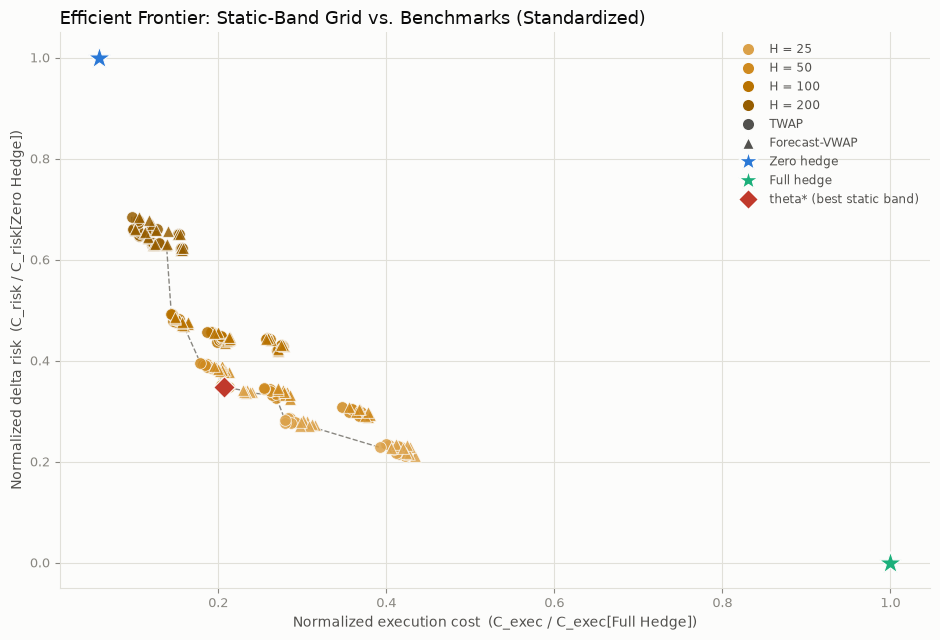

Wrote figure to outputs/figures/efficient_frontier_cost_vs_risk.png
Pareto-efficient configurations: 45 of 216

Pareto-frontier composition by execution method:


,n_frontier_points
method,
TWAP,29
Forecast-VWAP,16



Global optimum lies on the Pareto frontier: True


,H,eps,cooldown_min,horizon_min,execution_method,cost_norm,risk_norm,L_std
0,200,0.1,30,60,TWAP,0.097108,0.684897,0.782005
1,200,0.0,30,60,TWAP,0.098210,0.658756,0.756966
3,200,0.0,30,60,Forecast-VWAP,0.100709,0.658205,0.758914
7,200,0.0,0,60,TWAP,0.105179,0.646133,0.751313
14,200,0.0,0,60,Forecast-VWAP,0.116348,0.643763,0.760111
19,200,0.0,0,30,TWAP,0.121169,0.629547,0.750716
24,200,0.0,0,30,Forecast-VWAP,0.122779,0.629470,0.752249
26,200,0.0,15,30,Forecast-VWAP,0.124161,0.629351,0.753512
33,200,0.0,30,30,Forecast-VWAP,0.138458,0.628798,0.767255
36,100,0.1,30,60,TWAP,0.144189,0.493200,0.637390


In [159]:
H_ORDER = sorted(grid_df['H'].unique())
H_COLORS = dict(zip(H_ORDER, BAND_RAMP))
METHOD_MARKERS = {'twap': 'o', 'vwap': '^'}


def pareto_frontier(df: pd.DataFrame, x_col: str, y_col: str) -> pd.DataFrame:
    """Non-dominated points when minimizing both x_col and y_col."""
    ordered = df.sort_values([x_col, y_col]).reset_index(drop=True)
    keep = []
    best_y = np.inf
    for i, row in ordered.iterrows():
        if row[y_col] < best_y:
            keep.append(i)
            best_y = row[y_col]
    return ordered.loc[keep]


frontier = pareto_frontier(grid_df, 'cost_norm', 'risk_norm')

fig, ax = plt.subplots(figsize=(9.5, 6.5))
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

for H in H_ORDER:
    for method, marker in METHOD_MARKERS.items():
        subset = grid_df.loc[grid_df['H'].eq(H) & grid_df['method'].eq(method)]
        ax.scatter(
            subset['cost_norm'], subset['risk_norm'], color=H_COLORS[H], marker=marker,
            s=70, alpha=0.85, edgecolor=SURFACE, linewidth=0.6, zorder=3,
        )

ax.plot(frontier['cost_norm'], frontier['risk_norm'], color=INK_MUTED, linewidth=1, linestyle='--', zorder=2)

ax.scatter(summary_table.loc[0, 'cost_norm'], summary_table.loc[0, 'risk_norm'], color=COLOR_ZERO_HEDGE, marker='*', s=280, edgecolor=SURFACE, linewidth=0.8, zorder=4)
ax.scatter(summary_table.loc[1, 'cost_norm'], summary_table.loc[1, 'risk_norm'], color=COLOR_FULL_HEDGE, marker='*', s=280, edgecolor=SURFACE, linewidth=0.8, zorder=4)
ax.scatter(theta_star['cost_norm'], theta_star['risk_norm'], color=COLOR_THETA_STAR, marker='D', s=120, edgecolor=SURFACE, linewidth=0.8, zorder=5)

handles = (
    [plt.Line2D([0], [0], marker='o', linestyle='', markerfacecolor=H_COLORS[H], markeredgecolor=SURFACE, markersize=9, label=f'H = {H}') for H in H_ORDER]
    + [plt.Line2D([0], [0], marker=marker, linestyle='', markerfacecolor=INK_SECONDARY, markeredgecolor=SURFACE, markersize=9, label=METHOD_LABELS.get(method,method.upper(),),) for method, marker in METHOD_MARKERS.items()]
    + [plt.Line2D([0], [0], marker='*', linestyle='', markerfacecolor=COLOR_ZERO_HEDGE, markeredgecolor=SURFACE, markersize=15, label='Zero hedge'),
       plt.Line2D([0], [0], marker='*', linestyle='', markerfacecolor=COLOR_FULL_HEDGE, markeredgecolor=SURFACE, markersize=15, label='Full hedge'),
       plt.Line2D([0], [0], marker='D', linestyle='', markerfacecolor=COLOR_THETA_STAR, markeredgecolor=SURFACE, markersize=10, label='theta* (best static band)')]
)
legend = ax.legend(handles=handles, loc='upper right', frameon=False, fontsize=8.5)
for text in legend.get_texts():
    text.set_color(INK_SECONDARY)

ax.set_title('Efficient Frontier: Static-Band Grid vs. Benchmarks (Standardized)', color=INK_PRIMARY, fontsize=13, loc='left')
ax.set_xlabel('Normalized execution cost  (C_exec / C_exec[Full Hedge])', color=INK_SECONDARY, fontsize=10)
ax.set_ylabel('Normalized delta risk  (C_risk / C_risk[Zero Hedge])', color=INK_SECONDARY, fontsize=10)
ax.grid(color=GRID_COLOR, linewidth=0.8)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
for side in ('left', 'bottom'):
    ax.spines[side].set_color(GRID_COLOR)
ax.tick_params(colors=INK_MUTED, labelsize=9)

fig.tight_layout()
fig_path = OUTPUT_FIGURE_DIR / 'efficient_frontier_cost_vs_risk.png'
fig.savefig(fig_path, dpi=150, facecolor=fig.get_facecolor())
plt.show()

print(
    f"Wrote figure to "
    f"{fig_path.relative_to(PROJECT_ROOT)}"
)

print(
    f"Pareto-efficient configurations: "
    f"{len(frontier)} of {len(grid_df)}"
)

frontier_method_counts = (
    frontier["method"]
    .map(METHOD_LABELS)
    .value_counts()
    .rename("n_frontier_points")
)

print("\nPareto-frontier composition by execution method:")
display(frontier_method_counts.to_frame())

theta_on_frontier = (
    np.isclose(
        frontier["cost_norm"],
        theta_star["cost_norm"],
    )
    & np.isclose(
        frontier["risk_norm"],
        theta_star["risk_norm"],
    )
).any()

assert theta_on_frontier

print(
    "\nGlobal optimum lies on the Pareto frontier:",
    theta_on_frontier,
)

frontier_display = frontier[
    [
        "H",
        "eps",
        "cooldown_min",
        "horizon_min",
        "method",
        "cost_norm",
        "risk_norm",
        "L_std",
    ]
].copy()

frontier_display["execution_method"] = (
    frontier_display["method"]
    .map(METHOD_LABELS)
)

frontier_display[
    [
        "H",
        "eps",
        "cooldown_min",
        "horizon_min",
        "execution_method",
        "cost_norm",
        "risk_norm",
        "L_std",
    ]
].head(10)

## 5. Benchmark Comparison vs. Zero Hedge and Full Hedge

The panels compare theta* against the two benchmarks on each objective separately -- cost
and risk sit on different scales, so they get their own axes rather than a dual-axis
chart.

In [150]:
benchmark_comparison = summary_table.copy()
benchmark_comparison['cost_vs_zero_hedge_pct'] = (benchmark_comparison['execution_cost'] / zero_hedge['execution_cost'] - 1) * 100
benchmark_comparison['cost_vs_full_hedge_pct'] = (benchmark_comparison['execution_cost'] / full_hedge['execution_cost'] - 1) * 100
benchmark_comparison['risk_vs_zero_hedge_pct'] = (benchmark_comparison['delta_risk_rms'] / zero_hedge['delta_risk_rms'] - 1) * 100
benchmark_comparison

,strategy,execution_cost,delta_risk_rms,cost_norm,risk_norm,L_std,cost_vs_zero_hedge_pct,cost_vs_full_hedge_pct,risk_vs_zero_hedge_pct
0,Zero Hedge,2.352403e+05,24801.238131,0.058358,1.000000,1.058358,0.000000,-94.164203,0.000000
1,Full Hedge,4.030988e+06,0.000000,1.000000,0.000000,1.000000,1613.561892,0.000000,-100.000000
2,"Static band theta* (H=25, eps=10%, cooldown=0m...",8.350144e+05,8619.633850,0.207149,0.347549,0.554697,254.962287,-79.285120,-65.245147


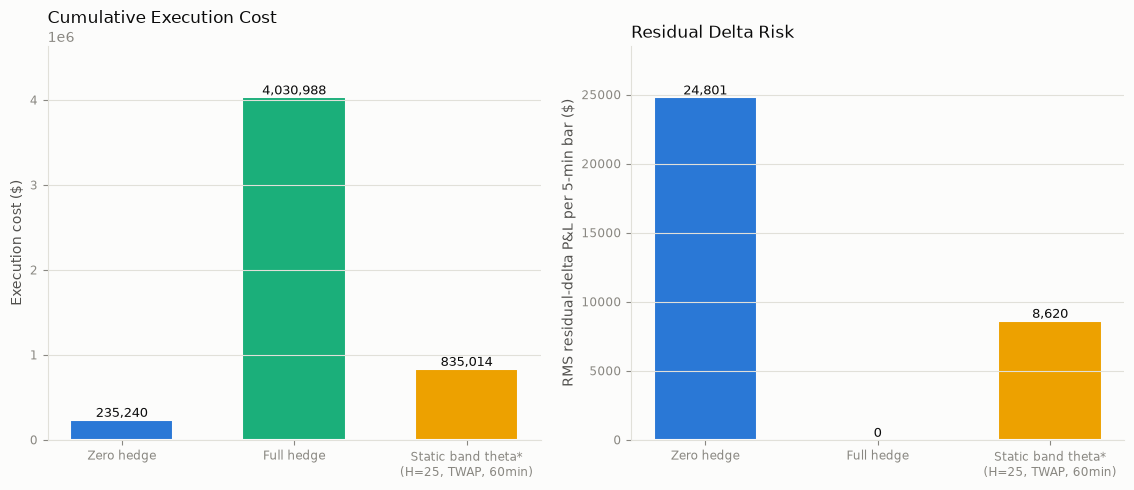

Wrote figure to outputs/figures/benchmark_comparison_cost_risk.png


In [151]:
labels = ['Zero hedge', 'Full hedge', f"Static band theta*\n(H={theta_star['H']:.0f}, {theta_star['method'].upper()}, {theta_star['horizon_min']:.0f}min)"]
colors = [COLOR_ZERO_HEDGE, COLOR_FULL_HEDGE, COLOR_STATIC_BAND]
cost_values = [zero_hedge['execution_cost'], full_hedge['execution_cost'], theta_star['execution_cost']]
risk_values = [zero_hedge['delta_risk_rms'], full_hedge['delta_risk_rms'], theta_star['delta_risk_rms']]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 5))
fig.patch.set_facecolor(SURFACE)

for ax, values, title, ylabel in (
    (axes[0], cost_values, 'Cumulative Execution Cost', 'Execution cost ($)'),
    (axes[1], risk_values, 'Residual Delta Risk', 'RMS residual-delta P&L per 5-min bar ($)'),
):
    ax.set_facecolor(SURFACE)
    bars = ax.bar(labels, values, color=colors, width=0.6, edgecolor=SURFACE, linewidth=1.5)
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, value, f'{value:,.0f}', ha='center', va='bottom', color=INK_PRIMARY, fontsize=9)
    ax.set_title(title, color=INK_PRIMARY, fontsize=12, loc='left')
    ax.set_ylabel(ylabel, color=INK_SECONDARY, fontsize=10)
    ax.set_ylim(top=max(values) * 1.15)
    ax.grid(axis='y', color=GRID_COLOR, linewidth=0.8)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    for side in ('left', 'bottom'):
        ax.spines[side].set_color(GRID_COLOR)
    ax.tick_params(colors=INK_MUTED, labelsize=8.5)

fig.tight_layout()
fig_path = OUTPUT_FIGURE_DIR / 'benchmark_comparison_cost_risk.png'
fig.savefig(fig_path, dpi=150, facecolor=fig.get_facecolor())
plt.show()

print(f'Wrote figure to {fig_path.relative_to(PROJECT_ROOT)}')

## 6. Sensitivity: Band Width H

Grouping the grid by `H` alone (averaged across eps, cooldown, horizon, and method).
Tighter bands trigger far more often and buy less residual risk per dollar; a band wide
enough to never be breached would collapse to the zero-hedge outcome exactly, since the
only hedge that ever fires is the end-of-day flatten (every `H` in this grid still
triggers -- see `avg_triggers_per_day`).

In [152]:
band_sensitivity = (
    grid_df.groupby('H')
    .agg(
        execution_cost=('execution_cost', 'mean'),
        delta_risk_rms=('delta_risk_rms', 'mean'),
        L_std=('L_std', 'mean'),
        n_triggers=('n_triggers', 'mean'),
    )
    .reset_index()
    .sort_values('H')
)
band_sensitivity['avg_triggers_per_day'] = band_sensitivity['n_triggers'] / n_days

never_triggered = band_sensitivity.loc[band_sensitivity['n_triggers'].eq(0), 'H'].tolist()
if never_triggered:
    print(f'Bands that are never breached in the backtest (identical to zero hedge): {never_triggered}')

band_sensitivity

,H,execution_cost,delta_risk_rms,L_std,n_triggers,avg_triggers_per_day
0,25,1.250757e+06,7006.915362,0.592808,654.666667,6.418301
1,50,1.118875e+06,8448.841611,0.618231,239.555556,2.348584
2,100,8.380123e+05,11235.219932,0.660903,67.240741,0.659223
3,200,5.217708e+05,15974.143241,0.773526,12.555556,0.123094


## 7. Sensitivity: Execution Horizon and TWAP vs. Forecast-VWAP

The horizon sweep is restricted to the most binding band, defined as the smallest
band width with at least one hedge trigger. Extending the execution horizon generally
reduces execution cost because the parent hedge is divided into smaller child orders,
but it may increase residual delta risk by leaving the book partially unhedged for longer.

The execution-method comparison uses the revised forecast-VWAP implementation.
Its child-order weights are estimated from a rolling 20-trading-day historical
intraday ES futures volume profile using only information available before the
current trading day. Realized future volume from the execution horizon is excluded.

In addition to comparing unconditional method averages, we conduct a paired comparison
between TWAP and forecast-VWAP across 108 otherwise identical parameter configurations.

In [161]:
# Execution-horizon sensitivity
binding_H = int(
    band_sensitivity.loc[
        band_sensitivity["n_triggers"].gt(0),
        "H",
    ].min()
)

horizon_sensitivity = (
    grid_df.loc[
        grid_df["H"].eq(binding_H)
    ]
    .groupby("horizon_min")
    .agg(
        execution_cost=("execution_cost", "mean"),
        delta_risk_rms=("delta_risk_rms", "mean"),
        L_std=("L_std", "mean"),
    )
    .reset_index()
    .sort_values("horizon_min")
)

print(
    f"Execution-horizon sensitivity "
    f"(H={binding_H}, the most binding band):"
)

display(horizon_sensitivity)

# Unconditional execution-method averages
method_sensitivity = (
    grid_df
    .groupby("method")
    .agg(
        execution_cost=("execution_cost", "mean"),
        delta_risk_rms=("delta_risk_rms", "mean"),
        L_std=("L_std", "mean"),
    )
    .reset_index()
)

method_sensitivity["execution_method"] = (
    method_sensitivity["method"]
    .map(METHOD_LABELS)
)

method_sensitivity_display = (
    method_sensitivity[
        [
            "execution_method",
            "execution_cost",
            "delta_risk_rms",
            "L_std",
        ]
    ]
    .sort_values("L_std")
    .reset_index(drop=True)
)

print(
    "\nTWAP vs. Forecast-VWAP "
    "(averaged over the rest of the grid):"
)

display(method_sensitivity_display)


# Paired comparison across matched parameter configurations
comparison_keys = [
    "H",
    "eps",
    "cooldown_min",
    "horizon_min",
]

comparison_metrics = [
    "execution_cost",
    "delta_risk_rms",
    "L_std",
]

twap_grid = (
    grid_df.loc[
        grid_df["method"].eq("twap"),
        comparison_keys + comparison_metrics,
    ]
    .rename(
        columns={
            metric: f"{metric}_twap"
            for metric in comparison_metrics
        }
    )
)

forecast_vwap_grid = (
    grid_df.loc[
        grid_df["method"].eq("vwap"),
        comparison_keys + comparison_metrics,
    ]
    .rename(
        columns={
            metric: f"{metric}_forecast_vwap"
            for metric in comparison_metrics
        }
    )
)

paired_method_comparison = twap_grid.merge(
    forecast_vwap_grid,
    on=comparison_keys,
    how="inner",
    validate="one_to_one",
)

assert len(paired_method_comparison) == 108

for metric in comparison_metrics:
    paired_method_comparison[
        f"{metric}_forecast_vwap_minus_twap"
    ] = (
        paired_method_comparison[
            f"{metric}_forecast_vwap"
        ]
        - paired_method_comparison[
            f"{metric}_twap"
        ]
    )

paired_summary = pd.DataFrame(
    [
        {
            "metric": metric,
            "mean_forecast_vwap_minus_twap": (
                paired_method_comparison[
                    f"{metric}_forecast_vwap_minus_twap"
                ].mean()
            ),
            "median_forecast_vwap_minus_twap": (
                paired_method_comparison[
                    f"{metric}_forecast_vwap_minus_twap"
                ].median()
            ),
            "forecast_vwap_better_share": (
                paired_method_comparison[
                    f"{metric}_forecast_vwap_minus_twap"
                ].lt(0)
                .mean()
            ),
        }
        for metric in comparison_metrics
    ]
)

print(
    "\nPaired TWAP versus Forecast-VWAP comparison "
    "across 108 matched configurations:"
)

display(paired_summary)

print(
    "\nPaired comparison validated:",
    len(paired_method_comparison),
    "matched configurations.",
)

Execution-horizon sensitivity (H=25, the most binding band):


,horizon_min,execution_cost,delta_risk_rms,L_std
0,15,1.673407e+06,5583.420916,0.640262
1,30,1.190623e+06,6890.894378,0.573212
2,60,8.882419e+05,8546.430792,0.564950



TWAP vs. Forecast-VWAP (averaged over the rest of the grid):


,execution_method,execution_cost,delta_risk_rms,L_std
0,TWAP,910234.766075,10701.614096,0.657304
1,Forecast-VWAP,954473.079684,10630.945977,0.665430



Paired TWAP versus Forecast-VWAP comparison across 108 matched configurations:


,metric,mean_forecast_vwap_minus_twap,median_forecast_vwap_minus_twap,forecast_vwap_better_share
0,execution_cost,44238.313609,40535.441772,0.009259
1,delta_risk_rms,-70.668118,-27.132557,0.861111
2,L_std,0.008125,0.008741,0.037037



Paired comparison validated: 108 matched configurations.


## 8. Sensitivity: Spread and Impact-Cost Assumptions

The spread and market-impact components are stored separately for every
configuration. Because spread cost scales linearly with the assumed half-spread
and impact cost scales linearly with the coefficient `alpha`, both assumptions
can be varied analytically without rerunning the backtest.

For each alternative cost assumption, the Full Hedge cost benchmark is rescaled
consistently, normalized execution cost is recomputed, and the optimal static-band
configuration is re-selected using the full standardized objective

`L_std = cost_norm + lambda_risk * risk_norm`.

Residual delta risk is unchanged by this analytical cost rescaling.
`IMPACT_BETA` is held fixed because changing the nonlinear participation exponent
would require rerunning the order-level simulation.

In [163]:
SPREAD_MULTIPLIERS = [0, 0.5, 1, 2, 4]
IMPACT_MULTIPLIERS = [0.5, 1, 2, 4]


def cost_sensitivity(kind, multipliers):
    """Re-select theta* after analytically rescaling spread or impact cost."""
    assert kind in {"spread", "impact"}
    rows = []

    for m in multipliers:
        spread_mult, impact_mult = (m, 1) if kind == "spread" else (1, m)

        test = grid_df.copy()
        test["execution_cost_scaled"] = (
            test["spread_cost"] * spread_mult
            + test["impact_cost"] * impact_mult
        )

        full_cost_scaled = (
            full_hedge["spread_cost"] * spread_mult
            + full_hedge["impact_cost"] * impact_mult
        )

        test["cost_norm_scaled"] = (
            test["execution_cost_scaled"] / full_cost_scaled
        )
        test["risk_norm_scaled"] = (
            test["delta_risk_rms"] / zero_hedge["delta_risk_rms"]
        )
        test["L_std_scaled"] = (
            test["cost_norm_scaled"]
            + LAMBDA_RISK_BASE * test["risk_norm_scaled"]
        )

        best = test.loc[test["L_std_scaled"].idxmin()]

        rows.append({
            "multiplier": m,
            "implied_value": (
                ES_HALF_SPREAD * m
                if kind == "spread"
                else IMPACT_ALPHA * m
            ),
            "H": int(best["H"]),
            "eps": best["eps"],
            "cooldown_min": int(best["cooldown_min"]),
            "horizon_min": int(best["horizon_min"]),
            "method": METHOD_LABELS.get(
                best["method"], best["method"].upper()
            ),
            "execution_cost": best["execution_cost_scaled"],
            "delta_risk_rms": best["delta_risk_rms"],
            "L_std": best["L_std_scaled"],
        })

    return pd.DataFrame(rows)


spread_sensitivity = cost_sensitivity(
    "spread", SPREAD_MULTIPLIERS
).rename(columns={
    "multiplier": "spread_multiplier",
    "implied_value": "half_spread_points",
})

impact_sensitivity = cost_sensitivity(
    "impact", IMPACT_MULTIPLIERS
).rename(columns={
    "multiplier": "impact_multiplier",
    "implied_value": "impact_alpha",
})

print("Spread sensitivity:")
display(spread_sensitivity)

print("\nImpact sensitivity:")
display(impact_sensitivity)

Spread sensitivity:


,spread_multiplier,half_spread_points,H,eps,cooldown_min,horizon_min,method,execution_cost,delta_risk_rms,L_std
0,0.0,0.0000,25,0.1,0,60,TWAP,7.312411e+05,8619.633850,0.542321
1,0.5,0.0625,25,0.1,0,60,TWAP,7.831277e+05,8619.633850,0.548729
2,1.0,0.1250,25,0.1,0,60,TWAP,8.350144e+05,8619.633850,0.554697
3,2.0,0.2500,25,0.1,15,30,TWAP,1.239756e+06,6858.621409,0.564348
4,4.0,0.5000,25,0.1,15,30,TWAP,1.463845e+06,6858.621409,0.577688



Impact sensitivity:


,impact_multiplier,impact_alpha,H,eps,cooldown_min,horizon_min,method,execution_cost,delta_risk_rms,L_std
0,0.5,0.0275,25,0.1,15,30,TWAP,6.198781e+05,6858.621409,0.564348
1,1.0,0.0550,25,0.1,0,60,TWAP,8.350144e+05,8619.633850,0.554697
2,2.0,0.1100,25,0.1,0,60,TWAP,1.566255e+06,8619.633850,0.548729
3,4.0,0.2200,25,0.1,0,60,TWAP,3.028738e+06,8619.633850,0.545583


## 9. Sensitivity: Risk-Penalty Weight (Eq. 28)

`L_std = cost_norm + lambda_risk * risk_norm`, with both terms stored per configuration,
so the risk-penalty weight can be swept analytically. This shows how risk-averse the desk
would have to be before Full Hedge overtakes the best static band.

In [165]:
LAMBDA_GRID = [0, 0.25, 0.5, 1, 2, 3, 4, 5, 7.5, 10]

rows = []

for lam in LAMBDA_GRID:
    test = grid_df.copy()
    test["L"] = test["cost_norm"] + lam * test["risk_norm"]
    best = test.loc[test["L"].idxmin()]

    full_L = 1.0
    zero_L = (
        zero_hedge["execution_cost"]
        / full_hedge["execution_cost"]
        + lam
    )

    candidates = {
        "Static Band": best["L"],
        "Full Hedge": full_L,
        "Zero Hedge": zero_L,
    }

    rows.append({
        "lambda_risk": lam,
        "best_overall": min(candidates, key=candidates.get),
        "H": int(best["H"]),
        "eps": best["eps"],
        "cooldown_min": int(best["cooldown_min"]),
        "horizon_min": int(best["horizon_min"]),
        "method": METHOD_LABELS.get(
            best["method"], best["method"].upper()
        ),
        "static_band_L": best["L"],
        "full_hedge_L": full_L,
        "zero_hedge_L": zero_L,
    })

lambda_sensitivity = pd.DataFrame(rows)

display(lambda_sensitivity)

full_threshold = lambda_sensitivity.loc[
    lambda_sensitivity["best_overall"].eq("Full Hedge"),
    "lambda_risk",
]

if full_threshold.empty:
    print("Full Hedge does not become optimal on the tested lambda grid.")
else:
    print(
        "Full Hedge becomes optimal once lambda_risk >=",
        full_threshold.min(),
    )

,lambda_risk,best_overall,H,eps,cooldown_min,horizon_min,method,static_band_L,full_hedge_L,zero_hedge_L
0,0.00,Zero Hedge,200,0.1,30,60,TWAP,0.097108,1.0,0.058358
1,0.25,Static Band,200,0.0,30,60,TWAP,0.262899,1.0,0.308358
2,0.50,Static Band,50,0.1,30,60,TWAP,0.376504,1.0,0.558358
3,1.00,Static Band,25,0.1,0,60,TWAP,0.554697,1.0,1.058358
4,2.00,Static Band,25,0.1,15,30,TWAP,0.832848,1.0,2.058358
5,3.00,Full Hedge,25,0.0,0,15,TWAP,1.057398,1.0,3.058358
6,4.00,Full Hedge,25,0.0,0,15,TWAP,1.268989,1.0,4.058358
7,5.00,Full Hedge,25,0.0,0,15,TWAP,1.480581,1.0,5.058358
8,7.50,Full Hedge,25,0.0,0,15,TWAP,2.009560,1.0,7.558358
9,10.00,Full Hedge,25,0.0,0,15,TWAP,2.538539,1.0,10.058358


Full Hedge becomes optimal once lambda_risk >= 3.0


## 10. Intraday Walk-Through: Book Delta by Strategy

The busiest trading day by option-trade count, contrasting Zero Hedge, Full Hedge, and
theta*. Nothing is re-simulated here: the Zero Hedge path is the revalued book delta from
`alex_book_delta_paths.csv`, Full Hedge is flat at zero by construction, and the theta*
residual path is reconstructed exactly as `book_delta + cumulative hedge fills` from the
`child_order` / `close_flatten` rows of the persisted hedge-trade log (the reconstruction
is asserted to end the day flat). Dots mark band triggers.

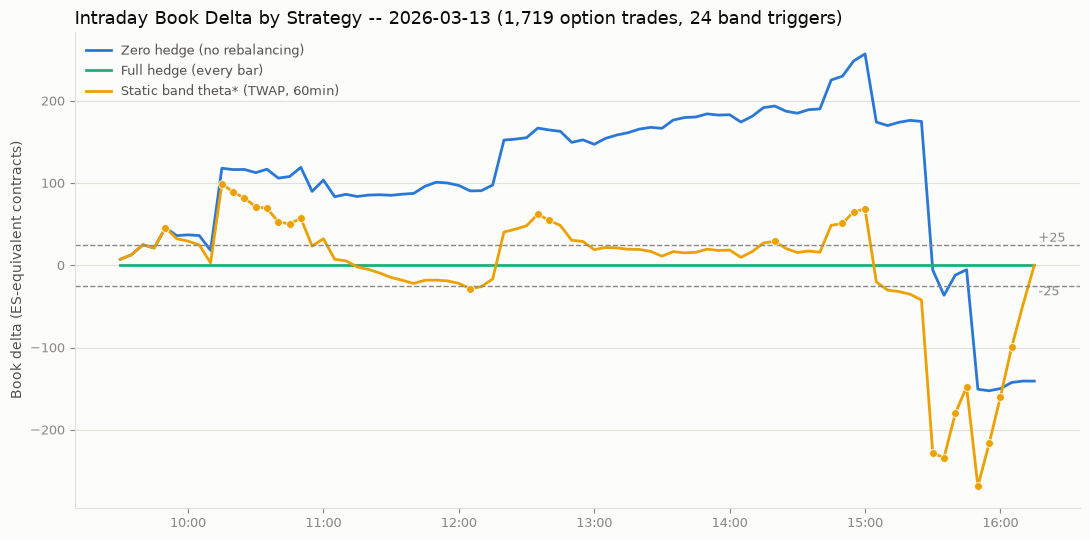

Wrote figure to outputs/figures/intraday_delta_path_by_strategy.png


In [166]:
def config_events(events: pd.DataFrame, theta: pd.Series) -> pd.DataFrame:
    """All hedge-trade events logged for one grid configuration."""
    mask = (
        events['band'].eq(theta['H'])
        & np.isclose(events['eps'], theta['eps'])
        & events['cooldown_minutes'].eq(theta['cooldown_min'])
        & events['horizon_minutes'].eq(theta['horizon_min'])
        & events['method'].eq(theta['method'])
    )
    return events.loc[mask]


star_events = config_events(hedge_events, theta_star)

busiest_day = book_paths.groupby('trade_date')['n_option_trades'].sum().idxmax()
day_bars = book_paths.loc[book_paths['trade_date'].eq(busiest_day)].sort_values('bar_time').reset_index(drop=True)
day_events = star_events.loc[star_events['trade_date'].eq(busiest_day)]

# Residual delta under theta* = revalued book delta + cumulative hedge fills. Fills are
# logged at the bar they execute, so a cumsum aligned on bar_time reproduces the engine's
# residual path exactly.
fills_by_bar = (
    day_events.loc[day_events['event_type'].isin(['child_order', 'close_flatten'])]
    .groupby('bar_time')['hedge_delta'].sum()
    .reindex(day_bars['bar_time'], fill_value=0.0)
)
hedge_cum = fills_by_bar.cumsum().to_numpy()

zero_path = day_bars['book_delta'].to_numpy()
full_path = np.zeros(len(day_bars))
static_path = zero_path + hedge_cum
assert abs(static_path[-1]) < 1e-6, 'theta* close_flatten should leave the book flat'

triggers = day_events.loc[day_events['event_type'].eq('trigger')]
n_trades_sample = int(day_bars['n_option_trades'].sum())

fig, ax = plt.subplots(figsize=(11, 5.5))
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

ax.plot(day_bars['bar_time'], zero_path, color=COLOR_ZERO_HEDGE, linewidth=2, label='Zero hedge (no rebalancing)')
ax.plot(day_bars['bar_time'], full_path, color=COLOR_FULL_HEDGE, linewidth=2, label='Full hedge (every bar)')
ax.plot(
    day_bars['bar_time'], static_path, color=COLOR_STATIC_BAND, linewidth=2,
    label=(f"Static band theta* "f"({METHOD_LABELS.get(theta_star['method'], theta_star['method'].upper())}, "f"{theta_star['horizon_min']:.0f}min)"),)
if not triggers.empty:
    ax.scatter(triggers['bar_time'], triggers['book_delta_after'], color=COLOR_STATIC_BAND, s=32,
               zorder=5, edgecolor=SURFACE, linewidth=0.6)

band_H = float(theta_star['H'])
ax.axhline(band_H, color=INK_MUTED, linestyle='--', linewidth=1)
ax.axhline(-band_H, color=INK_MUTED, linestyle='--', linewidth=1)
ax.text(day_bars['bar_time'].iloc[-1], band_H, f' +{band_H:,.0f}', color=INK_MUTED, fontsize=9, va='bottom')
ax.text(day_bars['bar_time'].iloc[-1], -band_H, f' -{band_H:,.0f}', color=INK_MUTED, fontsize=9, va='top')

ax.set_title(
    f'Intraday Book Delta by Strategy -- {busiest_day.date()} ({n_trades_sample:,} option trades, {len(triggers)} band triggers)',
    color=INK_PRIMARY, fontsize=13, loc='left',
)
ax.set_ylabel('Book delta (ES-equivalent contracts)', color=INK_SECONDARY, fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.grid(axis='y', color=GRID_COLOR, linewidth=0.8)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
for side in ('left', 'bottom'):
    ax.spines[side].set_color(GRID_COLOR)
ax.tick_params(colors=INK_MUTED, labelsize=9)

legend = ax.legend(loc='upper left', frameon=False, fontsize=9)
for text in legend.get_texts():
    text.set_color(INK_SECONDARY)

fig.tight_layout()
fig_path = OUTPUT_FIGURE_DIR / 'intraday_delta_path_by_strategy.png'
fig.savefig(fig_path, dpi=150, facecolor=fig.get_facecolor())
plt.show()

print(f'Wrote figure to {fig_path.relative_to(PROJECT_ROOT)}')

## 11. Delta P&L: The Cost of Carrying Unhedged Exposure

Book delta only shows exposure; this converts each strategy's residual-delta path into a
cumulative mark-to-market P&L: `pnl_bar = resid[t-1] * (es1_price[t] - es1_price[t-1]) *
$50`, cumulated across the day (the same quantity Eq. 22 uses for the risk measure). Full
Hedge stays flat at zero by construction (it never carries delta between bars); Zero Hedge
and theta* show how much directional P&L the book absorbs by not being immediately
flat.

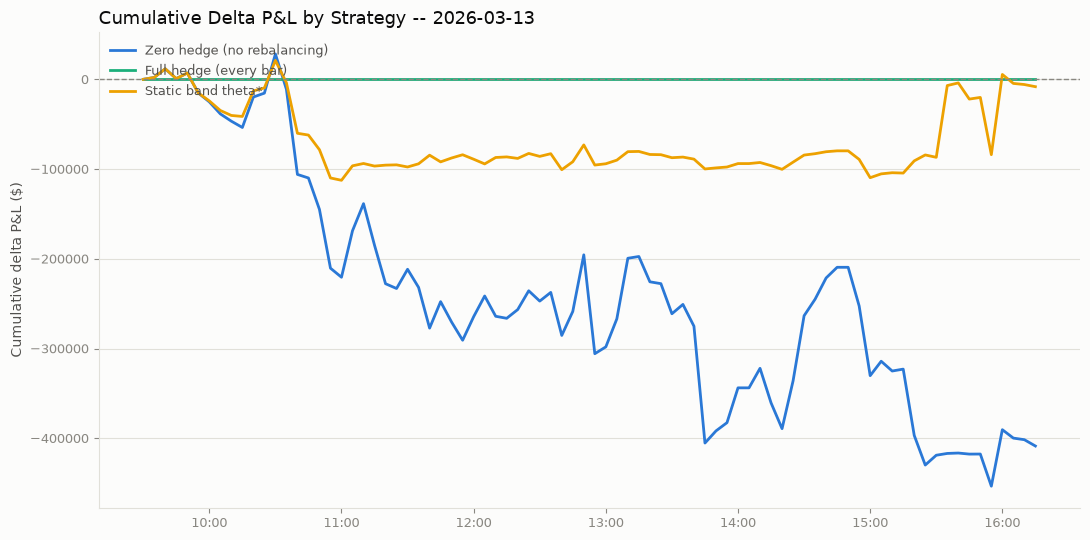

Wrote figure to outputs/figures/intraday_delta_pnl_by_strategy.png
End-of-day delta P&L -- zero hedge: -408,664, full hedge: 0, static band theta*: -8,198


In [168]:
def compute_delta_pnl(resid: np.ndarray, price: np.ndarray) -> np.ndarray:
    """Cumulative mark-to-market P&L ($) from carrying resid[t-1] ES contracts through
    the price move to t: contracts x points x $50 per point."""
    price_diff = np.diff(price, prepend=price[0])
    resid_prev = np.concatenate([[0.0], resid[:-1]])
    return np.cumsum(ES_MULTIPLIER * resid_prev * price_diff)


price_sample = day_bars['es1_price'].to_numpy()
zero_pnl = compute_delta_pnl(zero_path, price_sample)
full_pnl = compute_delta_pnl(full_path, price_sample)
static_pnl = compute_delta_pnl(static_path, price_sample)

fig, ax = plt.subplots(figsize=(11, 5.5))
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

ax.plot(day_bars['bar_time'], zero_pnl, color=COLOR_ZERO_HEDGE, linewidth=2, label='Zero hedge (no rebalancing)')
ax.plot(day_bars['bar_time'], full_pnl, color=COLOR_FULL_HEDGE, linewidth=2, label='Full hedge (every bar)')
ax.plot(day_bars['bar_time'], static_pnl, color=COLOR_STATIC_BAND, linewidth=2, label='Static band theta*')
ax.axhline(0, color=INK_MUTED, linestyle='--', linewidth=1)

ax.set_title(f'Cumulative Delta P&L by Strategy -- {busiest_day.date()}', color=INK_PRIMARY, fontsize=13, loc='left')
ax.set_ylabel('Cumulative delta P&L ($)', color=INK_SECONDARY, fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.grid(axis='y', color=GRID_COLOR, linewidth=0.8)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
for side in ('left', 'bottom'):
    ax.spines[side].set_color(GRID_COLOR)
ax.tick_params(colors=INK_MUTED, labelsize=9)

legend = ax.legend(loc='upper left', frameon=False, fontsize=9)
for text in legend.get_texts():
    text.set_color(INK_SECONDARY)

fig.tight_layout()
fig_path = OUTPUT_FIGURE_DIR / 'intraday_delta_pnl_by_strategy.png'
fig.savefig(fig_path, dpi=150, facecolor=fig.get_facecolor())
plt.show()

print(f'Wrote figure to {fig_path.relative_to(PROJECT_ROOT)}')
print(f'End-of-day delta P&L -- zero hedge: {zero_pnl[-1]:,.0f}, full hedge: {full_pnl[-1]:,.0f}, static band theta*: {static_pnl[-1]:,.0f}')

## 12. theta* Unified Trade Blotter: Option Trades, ES Hedges, and Portfolio Delta

The trade-level view of the recommended strategy, with everything the book trades in one
log:

- **`option_trade`** rows -- every executed option print from the tape
  (`executed_trade_delta_arrivals.csv`, written by notebook 02 with the same Eq. 11 unit
  convention the Alex engine uses), with its arrival delta in ES-contract equivalents
  (`delta_traded = s_i * n_i * delta_i`, no multiplier);
- **`trigger` / `child_order` / `close_flatten`** rows -- every ES hedge event of theta*
  from the persisted hedge log (`trigger` = parent order decided, nothing traded yet, so
  `delta_traded = 0` and `quantity` shows the parent size);
- **`bar_mark`** rows -- one per 5-minute bar (timestamped at the bar close, so each
  sorts after that bar's trades and events), carrying the bar-close portfolio state and
  **`delta_pnl`**: the mark-to-market P&L of carrying the previous bar's portfolio delta
  through this bar's ES price move (`$50 x portfolio_delta[t-1] x (price[t] -
  price[t-1])`, the same Eq. 22 grain the risk measure uses; zero at each day's first
  bar). Trade and event rows leave `delta_pnl` empty.

Each row also carries the theta* portfolio state at its timestamp: the revalued option
book delta (Eq. 17-19), the cumulative ES hedge position, and their sum -- the
**portfolio delta**. ES hedge rows use the engine's own logged after-event residual;
option rows use the bar-close state of their 5-minute bar, because under continuous
revaluation a per-trade frozen-delta running sum would not reconcile with the engine (see
the header note on the retired FIFO attribution) -- so option prints within the same bar
share that bar's closing portfolio delta.

Outputs: the full blotter is written to `outputs/tables/alex_theta_star_trade_blotter.csv`
and the per-bar portfolio-delta path (every 5-minute timestamp, including bars with no
trades, with the same `delta_pnl` column) to
`outputs/tables/alex_theta_star_portfolio_delta_by_bar.csv`. Both files are
configuration-specific, so their first line is a `#` comment stamping the theta*
parameters and the engine cost model they were generated under -- read them back with
`pd.read_csv(..., comment='#')`. The sample day from Section 10 is previewed below.

In [171]:
# --- Option legs: the executed option tape with per-trade arrival deltas (Eq. 11). ---
option_trades = pd.read_csv(
    DELTA_ARRIVALS_PATH,
    usecols=['trade_id', 'timestamp_et', 'bar_time', 'trade_date', 'symbol', 'side',
             'quantity', 'exec_price', 'delta', 'signed_delta_contracts'],
    parse_dates=['timestamp_et', 'bar_time', 'trade_date'],
)
assert len(option_trades) == book_paths['n_option_trades'].sum(), \
    'option tape must match the per-bar trade counts persisted by notebook 04'

# --- theta* portfolio state at every 5-minute bar: revalued book delta + cumulative ES
# hedge fills (the same residual construction as Section 10, extended to all days). ---
star_fills = star_events.loc[star_events['event_type'].isin(['child_order', 'close_flatten'])]
fills_per_bar = star_fills.groupby('bar_time')['hedge_delta'].sum()

portfolio_by_bar = (
    book_paths[['trade_date', 'bar_time', 'es1_price', 'book_delta']]
    .sort_values('bar_time')
    .reset_index(drop=True)
)
portfolio_by_bar['es_hedge_position'] = (
    portfolio_by_bar['bar_time'].map(fills_per_bar).fillna(0.0)
    .groupby(portfolio_by_bar['trade_date']).cumsum()
)
portfolio_by_bar['portfolio_delta'] = portfolio_by_bar['book_delta'] + portfolio_by_bar['es_hedge_position']
assert portfolio_by_bar.groupby('trade_date')['portfolio_delta'].last().abs().max() < 1e-6, \
    'theta* close_flatten should leave every day flat'

# Per-bar delta P&L (the Eq. 22 grain, same convention as Section 11): $50 x previous
# bar's portfolio delta x this bar's ES price move, restarting at zero each day.
portfolio_by_bar['delta_pnl'] = (
    ES_MULTIPLIER
    * portfolio_by_bar.groupby('trade_date')['portfolio_delta'].shift()
    * portfolio_by_bar.groupby('trade_date')['es1_price'].diff()
).fillna(0.0)
busiest_day_pnl = portfolio_by_bar.loc[portfolio_by_bar['trade_date'].eq(busiest_day), 'delta_pnl'].sum()
assert abs(busiest_day_pnl - static_pnl[-1]) < 1e-6, \
    'per-bar delta_pnl must reconcile with the Section 11 walk-through'

# Both theta* CSVs are configuration-specific, so their first line stamps the exact
# parameters they were generated under (read them back with pd.read_csv(..., comment='#')).
THETA_STAR_HEADER = (
    f"# theta* configuration: H={theta_star['H']:.0f} contracts, eps={theta_star['eps']:.0%}, "
    f"T_cooldown={theta_star['cooldown_min']:.0f} min, method={theta_star['method'].upper()}, "
    f"tau={theta_star['horizon_min']:.0f} min -- selected in Section 3 by minimizing L_std at "
    f"lambda={LAMBDA_RISK_BASE:g} (Eq. 24-28); engine cost model (notebook 04): "
    f"alpha={IMPACT_ALPHA:g}, beta={IMPACT_BETA:g}, half-spread={ES_HALF_SPREAD:g} pt, "
    f"closing-auction impact factor {CLOSE_IMPACT_FACTOR:g}"
)


def to_csv_with_config_header(df: pd.DataFrame, path: Path) -> None:
    with open(path, 'w', newline='', encoding='utf-8') as f:
        f.write(THETA_STAR_HEADER + '\n')
        df.to_csv(f, index=False)


path_by_bar = OUTPUT_TABLE_DIR / 'alex_theta_star_portfolio_delta_by_bar.csv'
to_csv_with_config_header(portfolio_by_bar, path_by_bar)

# --- Unified blotter: one row per option print, per ES hedge event, and per 5-min bar. ---
bar_state = portfolio_by_bar.set_index('bar_time')

option_rows = pd.DataFrame({
    'trade_date': option_trades['trade_date'],
    'timestamp': option_trades['timestamp_et'],
    'bar_time': option_trades['bar_time'],
    'event_type': 'option_trade',
    'instrument': option_trades['symbol'],
    'side': option_trades['side'],
    'quantity': option_trades['quantity'].astype(float),
    'price': option_trades['exec_price'],
    'option_delta': option_trades['delta'],
    'delta_traded': option_trades['signed_delta_contracts'],
    'exec_cost': np.nan,
    'spread_cost': np.nan,
    'impact_cost': np.nan,
    # Bar-close state: intra-bar per-trade attribution would not reconcile under
    # continuous revaluation (header note), so option prints carry their bar's close.
    'book_delta': option_trades['bar_time'].map(bar_state['book_delta']),
    'es_hedge_position': option_trades['bar_time'].map(bar_state['es_hedge_position']),
    'portfolio_delta': option_trades['bar_time'].map(bar_state['portfolio_delta']),
    'delta_pnl': np.nan,
})

se = star_events.reset_index(drop=True)
se_is_trigger = se['event_type'].eq('trigger')
se_book_delta = se['bar_time'].map(bar_state['book_delta'])
es_rows = pd.DataFrame({
    'trade_date': se['trade_date'],
    'timestamp': se['bar_time'],
    'bar_time': se['bar_time'],
    'event_type': se['event_type'],
    'instrument': 'ES1',
    'side': np.where(se['hedge_delta'] >= 0, 'BUY', 'SELL'),
    'quantity': se['hedge_delta'].abs(),
    'price': np.where(se_is_trigger, np.nan, se['bar_time'].map(bar_state['es1_price'])),
    'option_delta': np.nan,
    'delta_traded': np.where(se_is_trigger, 0.0, se['hedge_delta']),
    'exec_cost': se['exec_cost'],
    'spread_cost': se['spread_cost'],
    'impact_cost': se['impact_cost'],
    'book_delta': se_book_delta,
    # book_delta_after is the engine's residual right after this event, so the implied
    # hedge position is exact even when a later fill moves the bar-close state.
    'es_hedge_position': se['book_delta_after'] - se_book_delta,
    'portfolio_delta': se['book_delta_after'],
    'delta_pnl': np.nan,
})

# One bar_mark row per 5-minute interval: bar-close delta exposure and the delta P&L
# accrued over the bar. Timestamped at the bar close so it sorts after that bar's
# intra-bar option prints and bar-open ES events.
bar_rows = pd.DataFrame({
    'trade_date': portfolio_by_bar['trade_date'],
    'timestamp': portfolio_by_bar['bar_time'] + pd.Timedelta(minutes=BAR_MINUTES),
    'bar_time': portfolio_by_bar['bar_time'],
    'event_type': 'bar_mark',
    'instrument': np.nan,
    'side': np.nan,
    'quantity': np.nan,
    'price': portfolio_by_bar['es1_price'],
    'option_delta': np.nan,
    'delta_traded': np.nan,
    'exec_cost': np.nan,
    'spread_cost': np.nan,
    'impact_cost': np.nan,
    'book_delta': portfolio_by_bar['book_delta'],
    'es_hedge_position': portfolio_by_bar['es_hedge_position'],
    'portfolio_delta': portfolio_by_bar['portfolio_delta'],
    'delta_pnl': portfolio_by_bar['delta_pnl'],
})

# Within a bar: ES events sit exactly at bar_time and execute in engine order
# (child fill, then trigger check, then the last bar's flatten); option prints carry
# their real intra-bar timestamps and sort after; the bar_mark closes out the bar.
EVENT_ORDER = {'child_order': 0, 'trigger': 1, 'close_flatten': 2, 'option_trade': 3, 'bar_mark': 4}
blotter = pd.concat([option_rows, es_rows, bar_rows], ignore_index=True)
blotter['event_rank'] = blotter['event_type'].map(EVENT_ORDER)
blotter = (
    blotter.sort_values(['bar_time', 'timestamp', 'event_rank'], kind='stable')
    .drop(columns='event_rank')
    .reset_index(drop=True)
)

blotter_path = OUTPUT_TABLE_DIR / 'alex_theta_star_trade_blotter.csv'
to_csv_with_config_header(blotter, blotter_path)
legacy_blotter = OUTPUT_TABLE_DIR / 'alex_theta_star_hedge_blotter.csv'
if legacy_blotter.exists():
    legacy_blotter.unlink()
    print(f'Removed the superseded hedge-only blotter {legacy_blotter.relative_to(PROJECT_ROOT)}')

n_triggers_star = int(se_is_trigger.sum())
print(THETA_STAR_HEADER)
print(f'theta* unified trade blotter over {n_days} trading days: {len(blotter):,} rows')
print(f"  option trades:  {len(option_trades):,} prints ({len(option_trades) / n_days:.1f}/day), "
      f"{option_trades['quantity'].sum():,.0f} option contracts, "
      f"{option_trades['signed_delta_contracts'].abs().sum():,.0f} ES-equivalent delta traded")
print(f"  band triggers:  {n_triggers_star:,} total ({n_triggers_star / n_days:.1f}/day)")
print(f"  ES hedge fills: {len(star_fills):,} total ({len(star_fills) / n_days:.1f}/day), "
      f"{star_fills['hedge_delta'].abs().sum():,.0f} ES contracts traded")
print(f"  execution cost: ${star_fills['exec_cost'].sum():,.0f} "
      f"(spread ${star_fills['spread_cost'].sum():,.0f} + impact ${star_fills['impact_cost'].sum():,.0f})")
print(f"  bar marks:      {len(bar_rows):,} rows (one per 5-minute bar; delta P&L sums to "
      f"${bar_rows['delta_pnl'].sum():,.0f} across the period)")
print(f'Wrote the full theta* blotter to {blotter_path.relative_to(PROJECT_ROOT)}')
print(f'Wrote the per-bar portfolio-delta path to {path_by_bar.relative_to(PROJECT_ROOT)}')
print()

# Preview a window around the sample day's first band trigger so the mix of option
# prints, triggers, child fills, and bar marks (with delta exposure and P&L) is visible.
PREVIEW_COLS = ['timestamp', 'event_type', 'instrument', 'side', 'quantity', 'price',
                'delta_traded', 'es_hedge_position', 'portfolio_delta', 'delta_pnl']
day_blotter = blotter.loc[blotter['trade_date'].eq(busiest_day)].reset_index(drop=True)
es_positions = day_blotter.index[day_blotter['instrument'].eq('ES1')]
preview_start = max(int(es_positions[0]) - 5, 0) if len(es_positions) else 0
print(f'Sample-day blotter ({busiest_day.date()}), around the first band trigger:')
day_blotter.iloc[preview_start:preview_start + 30][PREVIEW_COLS]

# theta* configuration: H=25 contracts, eps=10%, T_cooldown=0 min, method=TWAP, tau=60 min -- selected in Section 3 by minimizing L_std at lambda=1 (Eq. 24-28); engine cost model (notebook 04): alpha=0.055, beta=0.5, half-spread=0.125 pt, closing-auction impact factor 0.15
theta* unified trade blotter over 102 trading days: 45,205 rows
  option trades:  32,127 prints (315.0/day), 661,367 option contracts, 66,054 ES-equivalent delta traded
  band triggers:  833 total (8.2/day)
  ES hedge fills: 3,881 total (38.0/day), 18,397 ES contracts traded
  execution cost: $835,014 (spread $103,773 + impact $731,241)
  bar marks:      8,364 rows (one per 5-minute bar; delta P&L sums to $395,850 across the period)
Wrote the full theta* blotter to outputs/tables/alex_theta_star_trade_blotter.csv
Wrote the per-bar portfolio-delta path to outputs/tables/alex_theta_star_portfolio_delta_by_bar.csv

Sample-day blotter (2026-03-13), around the first band trigger:


,timestamp,event_type,instrument,side,quantity,price,delta_traded,es_hedge_position,portfolio_delta,delta_pnl
132,2026-03-13 09:49:35,option_trade,ESH6 P6600,BUY,1.000000,57.963908,-0.272214,0.0,20.944467,NaN
133,2026-03-13 09:49:44,option_trade,ESH6 P6000,SELL,1.000000,5.203818,0.000144,0.0,20.944467,NaN
134,2026-03-13 09:49:49,option_trade,ESH6 C6935,BUY,2.000000,3.255584,0.335202,0.0,20.944467,NaN
135,2026-03-13 09:49:54,option_trade,ESH6 P5900,BUY,4.000000,4.082537,-0.000064,0.0,20.944467,NaN
136,2026-03-13 09:50:00,bar_mark,NaN,NaN,NaN,6724.000000,NaN,0.0,20.944467,-10927.883265
137,2026-03-13 09:50:00,trigger,ES1,SELL,45.703911,NaN,0.000000,0.0,45.703911,NaN
138,2026-03-13 09:50:04,option_trade,ESH6 P5000,SELL,50.000000,0.888816,0.000000,0.0,45.703911,NaN
139,2026-03-13 09:50:08,option_trade,ESH6 P6500,SELL,1.000000,40.812367,0.131784,0.0,45.703911,NaN
140,2026-03-13 09:50:15,option_trade,ESM6 C7450,BUY,2.000000,16.068465,0.418596,0.0,45.703911,NaN
141,2026-03-13 09:50:28,option_trade,ESH6 C6975,BUY,2.000000,1.412460,0.263729,0.0,45.703911,NaN


## 13. Final Recommendation

In [172]:
cost_save = 100 * (1 - theta_star["cost_norm"])
risk_save = 100 * (1 - theta_star["risk_norm"])
total_save = full_hedge["execution_cost"] - theta_star["execution_cost"]
method_label = METHOD_LABELS.get(
    theta_star["method"], theta_star["method"].upper()
)

paired_L = paired_summary.loc[
    paired_summary["metric"].eq("L_std")
].iloc[0]

vwap_win_share = paired_L["forecast_vwap_better_share"]
vwap_wins = int(round(vwap_win_share * len(paired_method_comparison)))

print(
    "Recommended configuration:\n"
    f"theta* = (H={theta_star['H']:.0f}, "
    f"eps={theta_star['eps']:.0%}, "
    f"cooldown={theta_star['cooldown_min']:.0f}min, "
    f"{method_label}, "
    f"horizon={theta_star['horizon_min']:.0f}min)\n"
)

print(
    f"Execution cost: ${theta_star['execution_cost']:,.0f} "
    f"({cost_save:.1f}% below Full Hedge)\n"
    f"Delta-risk RMS: ${theta_star['delta_risk_rms']:,.0f} per bar "
    f"({risk_save:.1f}% below Zero Hedge)\n"
    f"L_std: {theta_star['L_std']:.3f} "
    f"(Zero Hedge={summary_table.loc[0, 'L_std']:.3f}, "
    f"Full Hedge={summary_table.loc[1, 'L_std']:.3f})\n"
)

print(
    f"Total execution-cost saving vs. Full Hedge: "
    f"${total_save:,.0f}, or approximately "
    f"${total_save / n_days:,.0f} per trading day.\n"
)

print(
    "Execution-method conclusion:\n"
    f"Forecast-VWAP achieved a lower L_std in only "
    f"{vwap_wins} of {len(paired_method_comparison)} matched configurations. "
    "Its small average risk reduction did not offset its higher execution cost, "
    "so TWAP remains the preferred execution method.\n"
)

print(
    "Robustness conclusion:\n"
    "TWAP remains optimal across all tested spread and impact assumptions. "
    "On the tested risk-aversion grid, Zero Hedge is optimal at lambda=0, "
    "the static-band strategy is optimal for lambda from 0.25 through 2, "
    "and Full Hedge first becomes optimal at lambda=3.\n"
)

print(
    "Implementation note:\n"
    "Forecast-VWAP uses a rolling 20-trading-day historical intraday "
    "volume profile and excludes current-day future realized volume, "
    "eliminating the earlier look-ahead bias.\n"
)

print(
    "Interpretation:\n"
    "The reported saving is an execution-cost saving rather than free P&L. "
    "Full Hedge pays more to maintain zero residual delta, while theta* "
    "accepts controlled intraday directional exposure and still enforces "
    "a delta-flat position at each market close."
)

Recommended configuration:
theta* = (H=25, eps=10%, cooldown=0min, TWAP, horizon=60min)

Execution cost: $835,014 (79.3% below Full Hedge)
Delta-risk RMS: $8,620 per bar (65.2% below Zero Hedge)
L_std: 0.555 (Zero Hedge=1.058, Full Hedge=1.000)

Total execution-cost saving vs. Full Hedge: $3,195,974, or approximately $31,333 per trading day.

Execution-method conclusion:
Forecast-VWAP achieved a lower L_std in only 4 of 108 matched configurations. Its small average risk reduction did not offset its higher execution cost, so TWAP remains the preferred execution method.

Robustness conclusion:
TWAP remains optimal across all tested spread and impact assumptions. On the tested risk-aversion grid, Zero Hedge is optimal at lambda=0, the static-band strategy is optimal for lambda from 0.25 through 2, and Full Hedge first becomes optimal at lambda=3.

Implementation note:
Forecast-VWAP uses a rolling 20-trading-day historical intraday volume profile and excludes current-day future realized vo